In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [24]:
import zipfile
import io

# Assuming 'archive (2).zip' is the name of your uploaded zip file
zip_file_name = list(uploaded.keys())[0]

# Unzip the file in memory
with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as z:
    # Assuming the CSV file inside is named 'StudentsPerformance.csv'
    # You might need to adjust this if the name is different
    with z.open('StudentsPerformance.csv') as f:
        df = pd.read_csv(f)

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [5]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [6]:
df["TotalScore"] = df["math score"] + df["reading score"] + df["writing score"]

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,TotalScore
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [7]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,TotalScore
0,0,1,1,1,1,72,72,74,218
1,0,2,4,1,0,69,90,88,247
2,0,1,3,1,1,90,95,93,278
3,1,0,0,0,1,47,57,44,148
4,1,2,4,1,1,76,78,75,229


In [8]:
X = df.drop("math score", axis=1)
y = df["math score"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2:", lr_r2)

Linear Regression RMSE: 2.961139431656772e-14
Linear Regression R2: 1.0


In [22]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest RMSE: 3.0441596541574487
Random Forest R2: 0.9619176093867634


In [21]:
gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting R2:", gb_r2)

Gradient Boosting RMSE: 3.210927710555816
Gradient Boosting R2: 0.957630785924395


In [20]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "RMSE": [lr_rmse, rf_rmse, gb_rmse],
    "R2 Score": [lr_r2, rf_r2, gb_r2]
})

print(results)

               Model          RMSE  R2 Score
0  Linear Regression  2.961139e-14  1.000000
1      Random Forest  3.044160e+00  0.961918
2  Gradient Boosting  3.211213e+00  0.957623


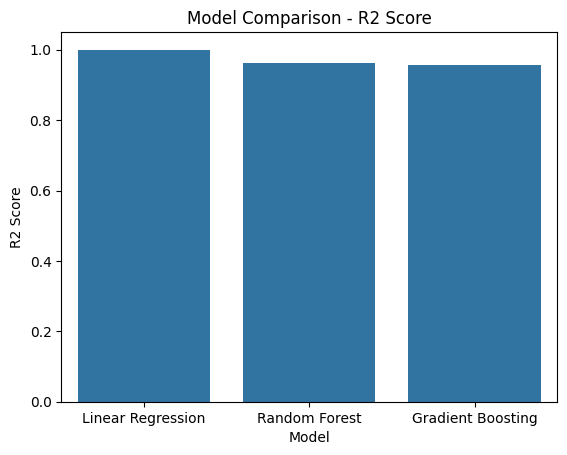

In [19]:
sns.barplot(x="Model", y="R2 Score", data=results)
plt.title("Model Comparison - R2 Score")
plt.show()

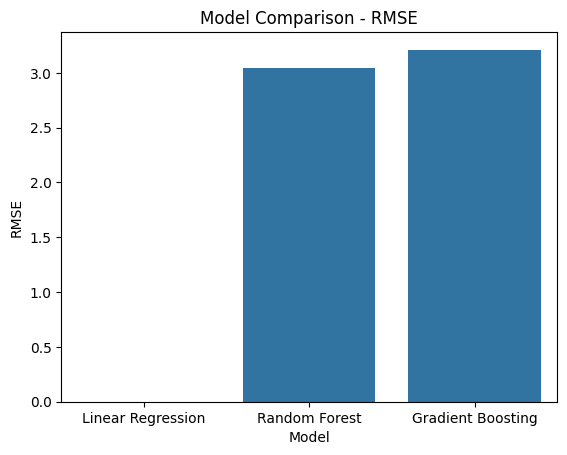

In [18]:
sns.barplot(x="Model", y="RMSE", data=results)
plt.title("Model Comparison - RMSE")
plt.show()

                       Feature  Importance
7                   TotalScore    0.881895
0                       gender    0.064825
5                reading score    0.022182
6                writing score    0.016793
1               race/ethnicity    0.004884
2  parental level of education    0.004561
3                        lunch    0.002529
4      test preparation course    0.002330


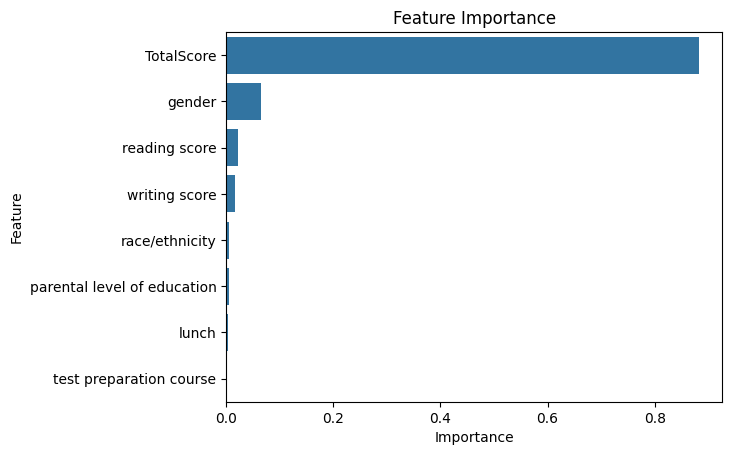

In [17]:
importance = rf.feature_importances_

feature_names = X.columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Feature Importance")
plt.show()